In [1]:
import polars as pl
import pandas as pd



In [2]:
filepath = "tracking_results/DeepEcoHAB_20260501_211615_007DLC_DekrW18_the_future_of_EcohabNov22shuffle1_snapshot_best-260_el.h5"

In [27]:
tracking_df = pd.read_hdf(filepath)

out_df = tracking_df.copy()
scorer = out_df.columns.get_level_values("scorer")[0]

long_pdf = (
    tracking_df
    .stack(["scorer", "individuals", "bodyparts"])
    #.rename(["x","y"])
    .reset_index()
)
tracking_lf = pl.from_pandas(long_pdf).lazy().rename({'level_0':"frame"}).drop('scorer') #ograć rename wczytywaniem z hdf

/tmp/ipykernel_829457/1113783982.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(["scorer", "individuals", "bodyparts"])


In [31]:
import numpy as np

tracking_lf = tracking_lf.filter(
    pl.col('bodyparts') == "Dorsal2",#to decide, maybe centroid instead
).sort(
    ["individuals", "frame"]
).with_columns(
    sum(pl.col(c).diff().over('individuals').pow(2) for c in ['x','y']).sqrt().alias('jump'),
    (pl.col("x").is_between(460,830) & pl.col("y").is_between(300,970)).fill_null(False).alias("center")
).with_columns(
    pl.when(
        ((pl.col("likelihood") >= 0.7) & (pl.col('jump') < 20) & (pl.col('center').not_()))#magic numbers 
    ).then(
        pl.col(c)
    ).otherwise(None).alias(c)
    for c in ["x", "y"]
).with_columns(
    [pl.col(c).interpolate().over("individuals").alias(c)
    for c in ["x", "y"]]
)
#.drop(pl.col("likelihood"))#.collect()

In [32]:
for coord in ["x", "y", "likelihood"]:
    wide_coord = tracking_lf.collect().pivot(
        index="frame",
        on="individuals",
        values=coord,
    )

    for individual in wide_coord.columns:
        out_df[(scorer, individual, "Dorsal2", coord)] = wide_coord[(individual)].to_numpy()

out_df.to_hdf(
    "DeepEcoHAB_20260501_211615_007DLC_DekrW18_the_future_of_EcohabNov22shuffle1_snapshot_best-260_el.h5",
    key="df_with_missing",
    mode="w",
)

tracking_lf.collect().to_pandas()

,frame,individuals,bodyparts,x,y,likelihood,jump,center
0,0,ind1,Dorsal2,NaN,NaN,0.383084,NaN,False
1,1,ind1,Dorsal2,NaN,NaN,0.413290,NaN,False
2,2,ind1,Dorsal2,NaN,NaN,0.416168,NaN,False
3,3,ind1,Dorsal2,NaN,NaN,0.423902,NaN,False
4,4,ind1,Dorsal2,NaN,NaN,0.440186,NaN,False
...,...,...,...,...,...,...,...,...
763037,107995,ind8,Dorsal2,999.233826,1061.965820,0.967108,1.112977,False
763038,107996,ind8,Dorsal2,998.334656,1062.909912,0.963555,1.303770,False
763039,107997,ind8,Dorsal2,998.671387,1062.973877,0.962898,0.342752,False
763040,107998,ind8,Dorsal2,998.540588,1063.556519,0.965019,0.597143,False


In [30]:
tracking_lf.with_columns(
    (pl.col(c).interpolate().over("individuals").alias(c)
    for c in ["x", "y"]),
).collect().to_pandas()

,frame,individuals,bodyparts,x,y,likelihood,jump,center
0,0,ind1,Dorsal2,NaN,NaN,0.383084,NaN,False
1,0,ind2,Dorsal2,NaN,NaN,0.528054,NaN,False
2,0,ind3,Dorsal2,NaN,NaN,0.813487,NaN,True
3,0,ind4,Dorsal2,NaN,NaN,0.850423,NaN,True
4,0,ind5,Dorsal2,NaN,NaN,0.923215,NaN,False
...,...,...,...,...,...,...,...,...
763037,107999,ind4,Dorsal2,NaN,NaN,0.852806,0.389091,True
763038,107999,ind5,Dorsal2,1108.964478,958.474060,0.914273,0.970226,False
763039,107999,ind6,Dorsal2,NaN,NaN,0.523328,0.010989,False
763040,107999,ind7,Dorsal2,415.452484,136.453751,0.975447,0.281263,False


In [7]:
antenna_df = pl.scan_csv(
    "tracking_results/DeepEcoHAB_20260501_211615_antenna_data.csv", 
    has_header=False,
    separator=";",
    new_columns=['antenna', 'tag', 'timestamp', 'datetime'],
    infer_schema_length=1000
    ).with_columns(
        pl.col('timestamp').str.to_integer(base=16)
    )

video_index = 7 #to extract from filename suffix
frames_per_video = 108000

antenna_df = antenna_df.with_columns(
    (pl.col('antenna')==10).cum_sum().alias('frame')
).filter(
    pl.col('frame').is_between(frames_per_video*video_index, frames_per_video*(video_index+1)-1)
).with_columns(
    (pl.col('frame')-pl.col('frame').first()).alias('frame')
)

In [8]:
antenna_df.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,10,01000000,13881021,2026-05-02T04:16:25.187506,0
1,10,01000000,13881025,2026-05-02T04:16:25.234955,1
2,10,01000000,13881028,2026-05-02T04:16:25.267095,2
3,10,01000000,13881031,2026-05-02T04:16:25.299101,3
4,10,01000000,13881035,2026-05-02T04:16:25.330489,4
...,...,...,...,...,...
115307,10,01000000,14241014,2026-05-02T05:16:25.269040,107995
115308,10,01000000,14241017,2026-05-02T05:16:25.300795,107996
115309,10,01000000,14241021,2026-05-02T05:16:25.341808,107997
115310,10,01000000,14241024,2026-05-02T05:16:25.371307,107998


In [9]:
antenna_df.filter(pl.col('tag')=='02000000').collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,1,02000000,14053249,2026-05-02T04:45:07.549451,51667


In [10]:
animal_detections = antenna_df.filter(
    pl.col("antenna") != 10#remove magic string
)

In [11]:
animal_detections.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725
...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451


In [12]:
animal_detections = animal_detections.with_columns(
    (
        pl.struct(["antenna", "tag"]).ne(pl.struct(["antenna", "tag"]).shift())
        | pl.col("frame").diff().gt(5)
    )
    .cum_sum()
    .cast(pl.Int16)
    .alias("run_id")
    .fill_null(0)
)
animal_detections.collect().to_pandas()
#group by run id of antenna and tag, with columns under antenna - in the future take the actual timestamp instead of frame

,antenna,tag,timestamp,datetime,frame,run_id
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722,0
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723,0
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724,0
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725,0
...,...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448,1459
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449,1459
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450,1459
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451,1459


In [13]:
antenna_with_coords = animal_detections.join(
    tracking_lf,
    on = 'frame',
    how = 'left'
)

In [14]:
antenna_with_coords = antenna_with_coords.filter((pl.col('tag') != '02000000') & (pl.col('tag') != '02000060')) #maybe use sanitation for that

In [15]:
antenna_with_coords.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y,likelihood,jump,center
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind1,Dorsal2,1044.807983,744.289185,0.955294,2.610515,False
1,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind2,Dorsal2,389.349856,141.763375,0.537632,429.252125,True
2,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind3,Dorsal2,NaN,NaN,0.820318,0.146796,True
3,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind4,Dorsal2,NaN,NaN,0.716963,0.237002,True
4,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind5,Dorsal2,201.814240,310.670593,0.924400,0.277763,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51522,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind4,Dorsal2,NaN,NaN,0.822526,0.191830,True
51523,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind5,Dorsal2,1131.467163,946.468811,0.934604,0.188446,False
51524,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind6,Dorsal2,389.522766,170.759018,0.946226,2.433174,False
51525,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind7,Dorsal2,170.023682,366.717133,0.972335,3.207791,False


In [16]:
antenna_with_coords.group_by(
    ['run_id', 'antenna', 'tag', 'individuals']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect().to_pandas()

,run_id,antenna,tag,individuals,x,y
0,799,5,EE1CEC1A,ind6,983.300232,284.266769
1,138,9,EE1CEC1A,ind6,1038.451111,856.346120
2,15,5,EE1CEC1A,ind3,850.618094,944.104774
3,571,7,EE1CEC1A,ind6,996.405782,1060.290324
4,979,6,12F5FF19,ind4,988.685849,1067.605646
...,...,...,...,...,...,...
10502,1121,8,DD43E61A,ind2,732.202718,827.127722
10503,925,6,DD43E61A,ind1,204.043269,284.635440
10504,970,4,3AFE9F1A,ind3,403.255920,127.299777
10505,822,1,EE1CEC1A,ind6,400.993549,968.222424


In [17]:
tst = antenna_with_coords.group_by(
    ['antenna']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect()

In [18]:
import numpy as np
img = np.zeros([1280, 1280])

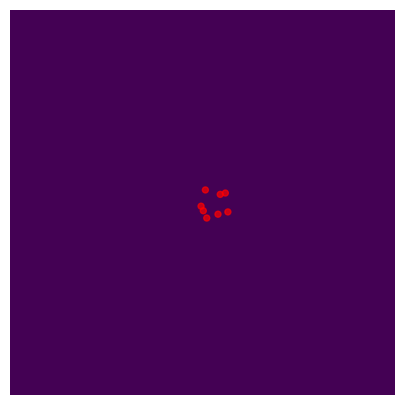

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
ax.axis('off')

for x in tst.to_numpy():
    circle = Circle((x[1], x[2]), 10, color='red', fill=True, alpha=0.7)
    ax.add_patch(circle)

plt.show()

In [20]:
antenna_with_coords.filter(
    pl.col('antenna') == 7
).with_columns(
    pl.col('x').floordiv(10)
).collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y,likelihood,jump,center
0,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind1,Dorsal2,30.0,1126.216064,0.961690,5.354684,False
1,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind2,Dorsal2,93.0,1123.691895,0.927952,1.849342,False
2,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind3,Dorsal2,84.0,931.223802,0.814230,0.725023,True
3,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind4,Dorsal2,NaN,NaN,0.533138,1.772167,False
4,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind5,Dorsal2,27.0,316.185333,0.888903,5.584064,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5282,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind4,Dorsal2,NaN,NaN,0.840509,0.060848,True
5283,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind5,Dorsal2,112.0,955.274536,0.893379,0.504621,False
5284,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind6,Dorsal2,46.0,245.456696,1.000000,1.187812,False
5285,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind7,Dorsal2,40.0,1096.478394,1.000000,0.595403,False


In [21]:
import polars as pl
data = [[510,250], [810,250], [1045,780], [1045,780], [810,1010], [510,1010], [270, 780], [270,480]]
antenna_locations = pl.DataFrame({"x":[510,810, 1045,1045,810,510,270,270], "y":[250,250,480,780,1010,1010,780,480]})
antenna_locations

x,y
i64,i64
510,250
810,250
1045,480
1045,780
810,1010
510,1010
270,780
270,480


In [22]:
antenna_with_coords_t = antenna_with_coords.select(['antenna', 'frame', 'tag', 'individuals', 'run_id', 'x', 'y'])

In [23]:
for i, d in enumerate(data):
    antenna_with_coords_t = antenna_with_coords_t.with_columns(
        (np.linalg.norm(np.array([pl.col("x"), pl.col("y")])- np.array([d[0], d[1]]))).alias(f"dist{i}")
    )

In [24]:
antenna_with_coords_t.filter(
    pl.col("dist1") < 150
).collect().to_pandas()

,antenna,frame,tag,individuals,run_id,x,y,dist0,dist1,dist2,dist3,dist4,dist5,dist6,dist7
0,5,2734,EE1CEC1A,ind7,25,927.752686,302.247925,421.007306,128.823680,491.928834,491.928834,717.480798,821.845671,812.948732,681.347485
1,5,2735,EE1CEC1A,ind7,25,920.942322,294.500031,413.344704,119.534311,501.099319,501.099319,724.050002,825.114415,812.056726,676.857551
2,5,2736,EE1CEC1A,ind7,25,917.056702,285.875122,408.634534,112.907758,510.420300,510.420300,731.995885,830.693684,814.150950,675.549290
3,5,2737,EE1CEC1A,ind7,25,912.650757,277.504486,403.589059,106.271702,519.632624,519.632624,739.653200,835.869194,815.782898,673.798507
4,5,2740,EE1CEC1A,ind7,25,896.442383,266.578186,386.797817,88.017736,534.482296,534.482296,748.430544,837.862583,809.958035,661.799766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452,1,105200,EE1CEC1A,ind6,1451,805.213719,338.093847,308.077369,88.223774,502.770831,502.770831,671.923200,733.899869,694.071158,553.706674
2453,1,105205,EE1CEC1A,ind6,1451,801.796542,332.004314,303.100527,82.413616,509.752937,509.752937,678.045314,738.121516,695.347177,552.005693
2454,1,105206,EE1CEC1A,ind6,1451,801.113107,330.786407,302.114687,81.273737,511.149361,511.149361,679.271729,738.970870,695.610512,551.675474
2455,1,105208,EE1CEC1A,ind6,1451,799.746236,328.350593,300.152789,79.018701,513.942210,513.942210,681.726524,740.674554,696.145287,551.025060
